# Import all Dependecies¶

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Df = pd.read_csv('Student.csv')

# Data understanding & Data Cleaning

In [3]:
Df.head(5)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [4]:
Df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [5]:
Df[['Sleep_Hours_Per_Night' , 'Mental_Health_Score' , 'Conflicts_Over_Social_Media' , 'Addicted_Score']].describe()

,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000
mean,6.868936,6.226950,2.849645,6.436879
std,1.126848,1.105055,0.957968,1.587165
min,3.800000,4.000000,0.000000,2.000000
25%,6.000000,5.000000,2.000000,5.000000
50%,6.900000,6.000000,3.000000,7.000000
75%,7.700000,7.000000,4.000000,8.000000
max,9.600000,9.000000,5.000000,9.000000


In [6]:
Df.isnull().sum().sum()

np.int64(0)

In [7]:
Df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

In [8]:
Df['Student_ID'].duplicated().sum()

np.int64(0)

In [9]:
Df.shape

(705, 13)

In [10]:
Df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')

In [11]:
Df.dtypes

Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status              object
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

In [12]:
Df["Avg_Daily_Usage_Hours"] = pd.to_numeric(Df["Avg_Daily_Usage_Hours"] , errors= 'coerce')
Df["Mental_Health_Score"] = pd.to_numeric(Df["Mental_Health_Score"] , errors = 'coerce')

In [13]:
Df["Avg_Daily_Usage_Hours"] = Df["Avg_Daily_Usage_Hours"].astype(int)
Df["Mental_Health_Score"] = Df["Mental_Health_Score"].astype(int)

In [14]:
Df["Relationship_Status"] = Df["Relationship_Status"].str.replace("Complicated", "No Relationship")

In [15]:
Df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6,TikTok,Yes,5.0,5,No Relationship,4,9
3,4,18,Male,High School,UK,3,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4,Twitter,No,7.5,8,Single,2,4


In [16]:
Df['Conflicts_Over_Social_Media'].value_counts()

Conflicts_Over_Social_Media
3    261
2    204
4    174
1     47
5     15
0      4
Name: count, dtype: int64

In [17]:
def Categories(row):
    if row['Conflicts_Over_Social_Media'] >= 0 and row['Conflicts_Over_Social_Media'] <= 2:
        return "Low"
    elif row['Conflicts_Over_Social_Media'] > 2 and row['Conflicts_Over_Social_Media'] <= 4:
        return "Medium"
    elif row['Conflicts_Over_Social_Media'] > 4:
        return "High"
    else:
        return'Nane'   # optional, if you want to handle 0 or negative values
Df['Conflicts_Over_Social_Media_category'] = Df.apply(Categories, axis=1)

In [18]:
Df['Addicted_Score'].value_counts()

Addicted_Score
7    209
8    144
5    136
4     83
6     61
9     55
3     16
2      1
Name: count, dtype: int64

In [19]:
def Categories(row):
    if row['Addicted_Score'] >= 0 and row['Addicted_Score'] <= 4:
        return "Low"
    elif row['Addicted_Score'] > 4 and row['Addicted_Score'] <= 7:
        return "Medium"
    elif row['Addicted_Score'] > 7:
        return "High"
    else:
        return'Nane'
Df['Addicted_Score_category'] = Df.apply(Categories, axis=1)

In [30]:
Df.rename(columns = {'Most_Used_Platform' : 'Platform'} , inplace = True)

In [31]:
Df.head(10)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Conflicts_Over_Social_Media_category,Addicted_Score_category
0,1,19,Female,Undergraduate,Bangladesh,5,Instagram,Yes,6.5,6,In Relationship,3,8,Medium,High
1,2,22,Male,Graduate,India,2,Twitter,No,7.5,8,Single,0,3,Low,Low
2,3,20,Female,Undergraduate,USA,6,TikTok,Yes,5.0,5,No Relationship,4,9,Medium,High
3,4,18,Male,High School,UK,3,YouTube,No,7.0,7,Single,1,4,Low,Low
4,5,21,Male,Graduate,Canada,4,Facebook,Yes,6.0,6,In Relationship,2,7,Low,Medium
5,6,19,Female,Undergraduate,Australia,7,Instagram,Yes,4.5,4,No Relationship,5,9,High,High
6,7,23,Male,Graduate,Germany,1,LinkedIn,No,8.0,9,Single,0,2,Low,Low
7,8,20,Female,Undergraduate,Brazil,5,Snapchat,Yes,6.0,6,In Relationship,2,8,Low,High
8,9,18,Male,High School,Japan,4,TikTok,No,6.5,7,Single,1,5,Low,Medium
9,10,21,Female,Graduate,South Korea,3,Instagram,No,7.0,7,In Relationship,1,4,Low,Low


# EDA


In [22]:
Total_student_Id = Df["Student_ID"].sum()

In [23]:
print(f"Total Student : {Total_student_Id}")

Total Student : 248865


# Most used platform by Gender

In [24]:
Df.head(5)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Conflicts_Over_Social_Media_category,Addicted_Score_category
0,1,19,Female,Undergraduate,Bangladesh,5,Instagram,Yes,6.5,6,In Relationship,3,8,Medium,High
1,2,22,Male,Graduate,India,2,Twitter,No,7.5,8,Single,0,3,Low,Low
2,3,20,Female,Undergraduate,USA,6,TikTok,Yes,5.0,5,No Relationship,4,9,Medium,High
3,4,18,Male,High School,UK,3,YouTube,No,7.0,7,Single,1,4,Low,Low
4,5,21,Male,Graduate,Canada,4,Facebook,Yes,6.0,6,In Relationship,2,7,Low,Medium


Gender  Platform 
Female  Facebook      24
        Instagram    172
        KakaoTalk     12
        LINE          12
        LinkedIn       8
        Snapchat       8
        TikTok        86
        Twitter       16
        WeChat         4
        WhatsApp      11
Male    Facebook      99
        Instagram     77
        LinkedIn      13
        Snapchat       5
        TikTok        68
        Twitter       14
        VKontakte     12
        WeChat        11
        WhatsApp      43
        YouTube       10
dtype: int64


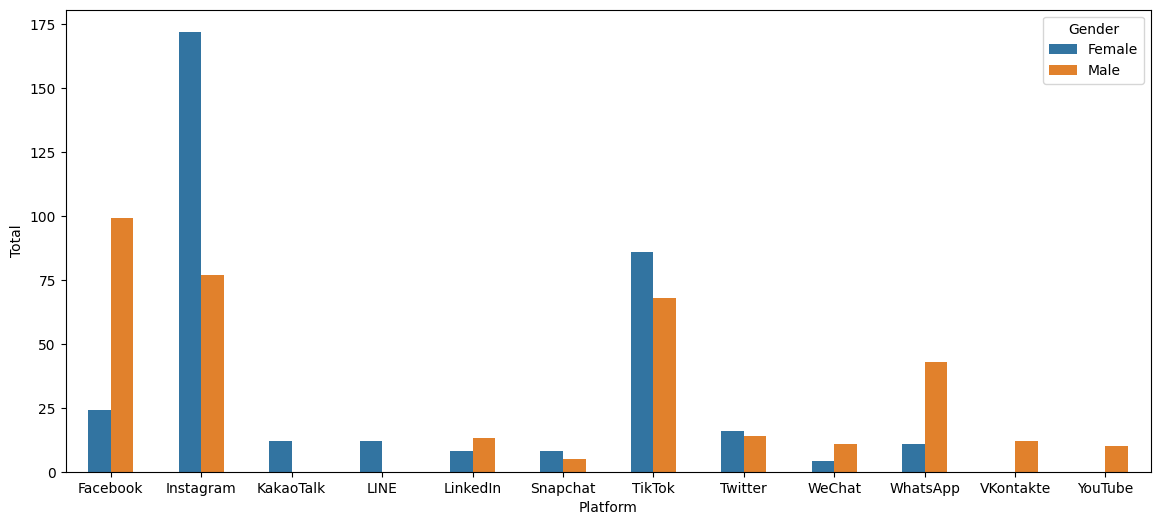

<Figure size 640x480 with 0 Axes>

In [25]:
Most_used_platform_by_Gender = Df.groupby(["Gender" , "Platform"]).size()
print(Most_used_platform_by_Gender)
Most_used_platform_by_Gender = Df.groupby(["Gender" , "Platform"]).size().reset_index(name = "Total")	
Most_used_platform_by_Gender

plt.figure(figsize=(14, 6))
sns.barplot(x = "Platform" , y = "Total" , data = Most_used_platform_by_Gender , width = 0.5 , hue = "Gender")
plt.show()
plt.tight_layout()

# Most used platform by Academic_Level

Academic_Level  Platform 
Graduate        Facebook      87
                Instagram     82
                LinkedIn      21
                TikTok        51
                Twitter       17
                VKontakte     12
                WeChat        12
                WhatsApp      43
High School     Instagram     12
                Snapchat       5
                TikTok         8
                YouTube        2
Undergraduate   Facebook      36
                Instagram    155
                KakaoTalk     12
                LINE          12
                Snapchat       8
                TikTok        95
                Twitter       13
                WeChat         3
                WhatsApp      11
                YouTube        8
dtype: int64


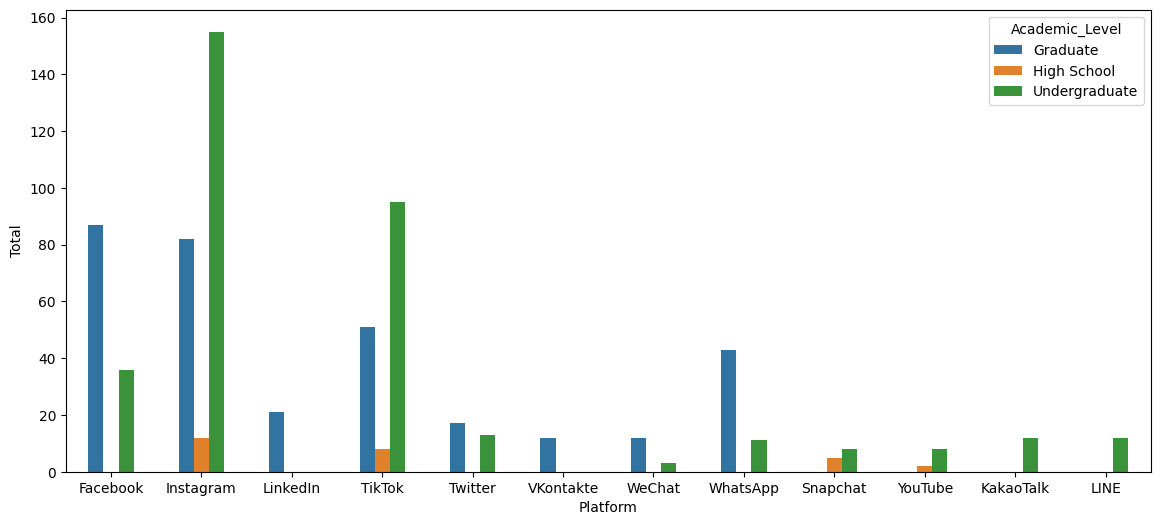

<Figure size 640x480 with 0 Axes>

In [26]:
Most_used_platform_by_Gender = Df.groupby(["Academic_Level" , "Platform"]).size()
print(Most_used_platform_by_Gender)
Most_used_platform_by_Gender = Df.groupby(["Academic_Level" , "Platform"]).size().reset_index(name = "Total")	
Most_used_platform_by_Gender

plt.figure(figsize=(14, 6))
sns.barplot(x = "Platform" , y = "Total" , data = Most_used_platform_by_Gender , width = 0.5 , hue = "Academic_Level")
plt.show()
plt.tight_layout()

# Most used platform by Age

In [27]:
Most_used_platform_by_Age = Df.groupby(["Age" , "Platform"]).size()
Most_used_platform_by_Age

Age  Platform 
18   Instagram     4
     Snapchat      4
     TikTok        5
     YouTube       1
19   Facebook      8
     Instagram    88
     LINE         12
     Snapchat      1
     TikTok       38
     Twitter       5
     WeChat        2
     WhatsApp      8
     YouTube       1
20   Facebook     21
     Instagram    64
     KakaoTalk    12
     Snapchat      6
     TikTok       52
     Twitter       4
     WhatsApp      3
     YouTube       3
21   Facebook     35
     Instagram    62
     LinkedIn      1
     Snapchat      2
     TikTok       20
     Twitter       4
     WeChat        5
     WhatsApp     22
     YouTube       5
22   Facebook     47
     Instagram    20
     LinkedIn      5
     TikTok       30
     Twitter       6
     VKontakte    12
     WeChat        6
     WhatsApp     21
23   Facebook      6
     Instagram     8
     LinkedIn     11
     TikTok        4
     Twitter       5
24   Facebook      6
     Instagram     3
     LinkedIn      4
     TikTok        

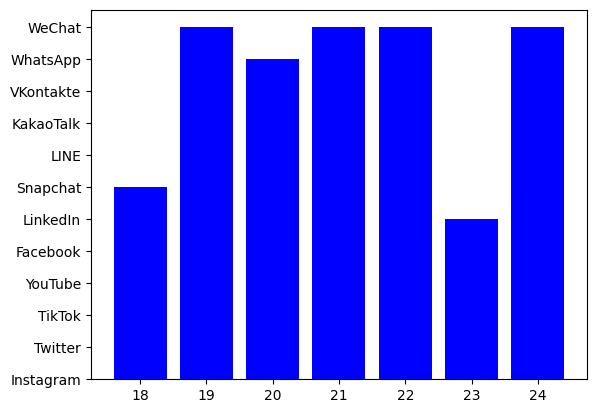

In [62]:
plt.bar(Df["Age"] , Df["Platform"] , color = "blue")
plt.show()

In [ ]:
print(Most_used_platform_by_Age)

# Which factor is contributing most to social media addiction

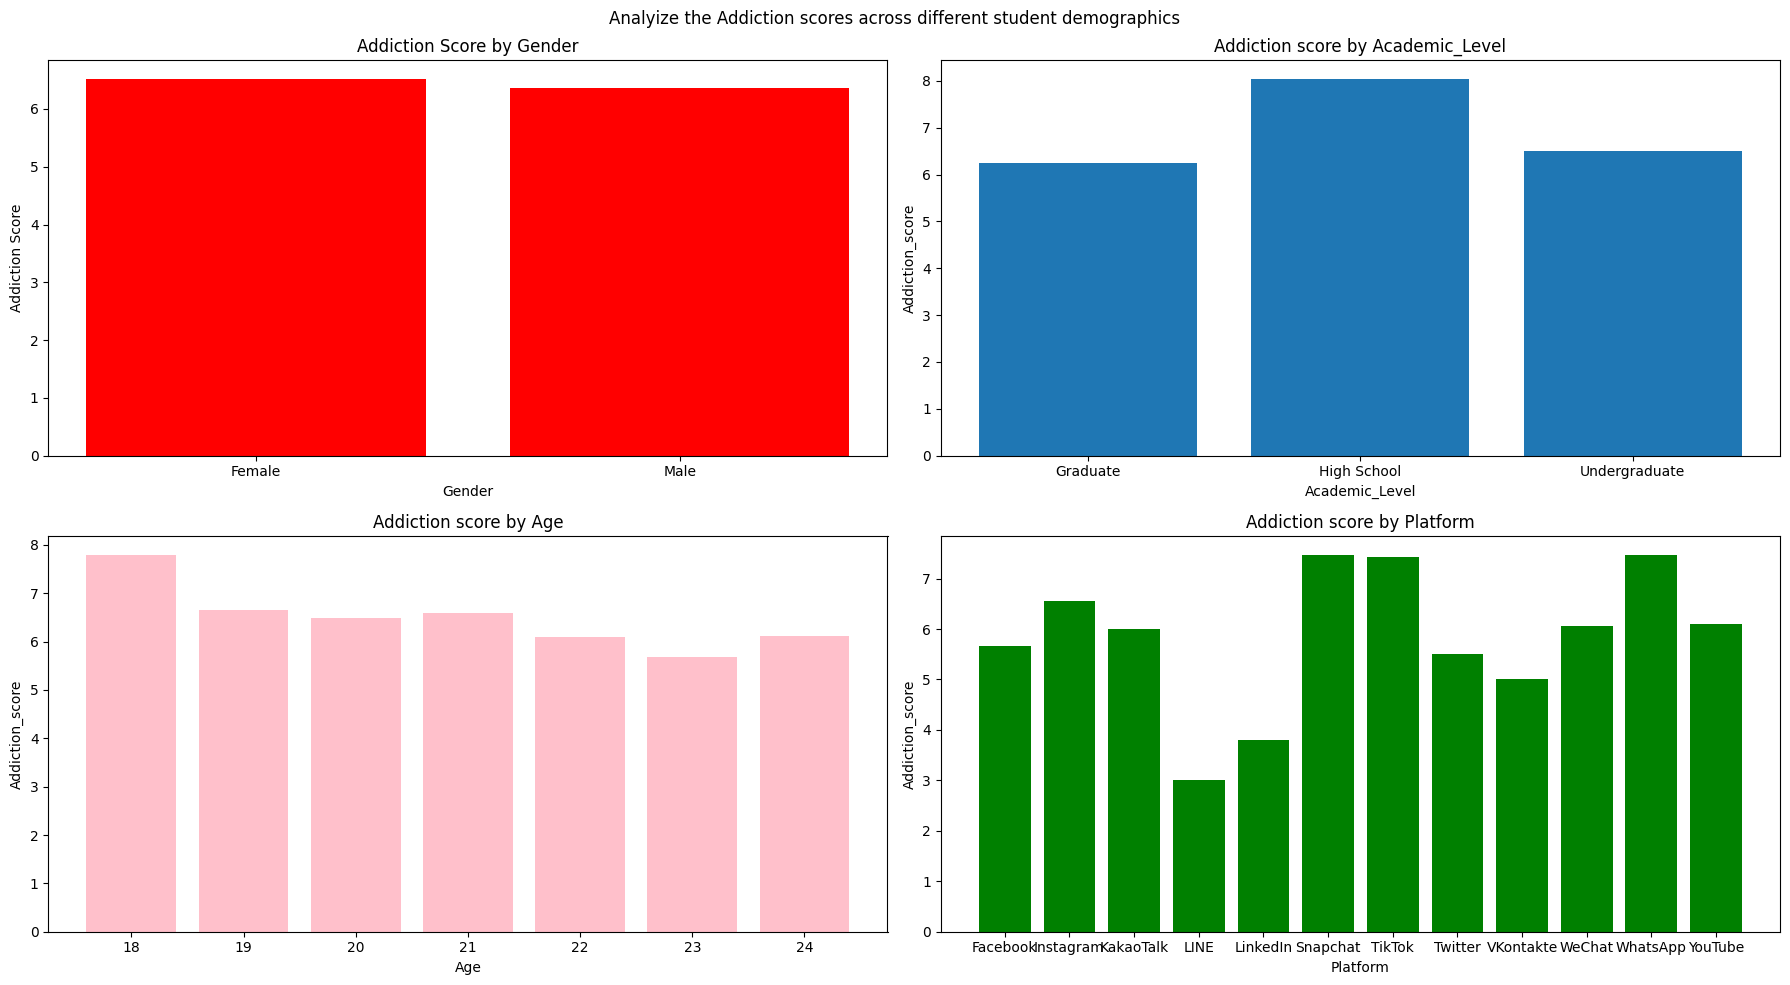

In [43]:
fig , ax = plt.subplots(2,2,figsize = (18,10))
fig.suptitle("Analyize the Addiction scores across different student demographics")

Gender_addiction = Df.groupby('Gender')['Addicted_Score'].mean()
ax[0, 0].bar(Gender_addiction.index, 
             Gender_addiction.values, 
             color='red')
ax[0, 0].set_xlabel("Gender")
ax[0, 0].set_ylabel("Addiction Score")
ax[0, 0].set_title("Addiction Score by Gender")
    
Academic_Level_addiction = Df.groupby('Academic_Level')['Addicted_Score'].mean()
ax[0 , 1].bar(Academic_Level_addiction.index , Academic_Level_addiction.values)
ax[0 , 1].set_xlabel('Academic_Level')
ax[0 , 1].set_ylabel("Addiction_score")
ax[0 , 1].set_title('Addiction score by Academic_Level')


Age_addiction = Df.groupby('Age')['Addicted_Score'].mean()
ax[1 , 0].bar(Age_addiction.index , Age_addiction.values , color = 'pink')
ax[1 , 0].set_xlabel('Age')
ax[1 , 0].set_ylabel("Addiction_score")
ax[1 , 0].set_title('Addiction score by Age')


Platform_addiction = Df.groupby('Platform')['Addicted_Score'].mean()
ax[1 , 1].bar(Platform_addiction.index , Platform_addiction.values , color = 'Green')
ax[1 , 1].set_xlabel('Platform')
ax[1 , 1].set_ylabel("Addiction_score")
ax[1 , 1].set_title('Addiction score by Platform')

plt.tight_layout()
# plt.savefig("image of line & bar chart1" , dpi = 300 , bbox_inches = "tight")

In [ ]:
# student data analysis chatgpt m h

# Analysis Effect of social media on Relationship

In [ ]:
Df.head(10)

Text(0.5, 1.0, 'Mental_Health_Score by Relationship')

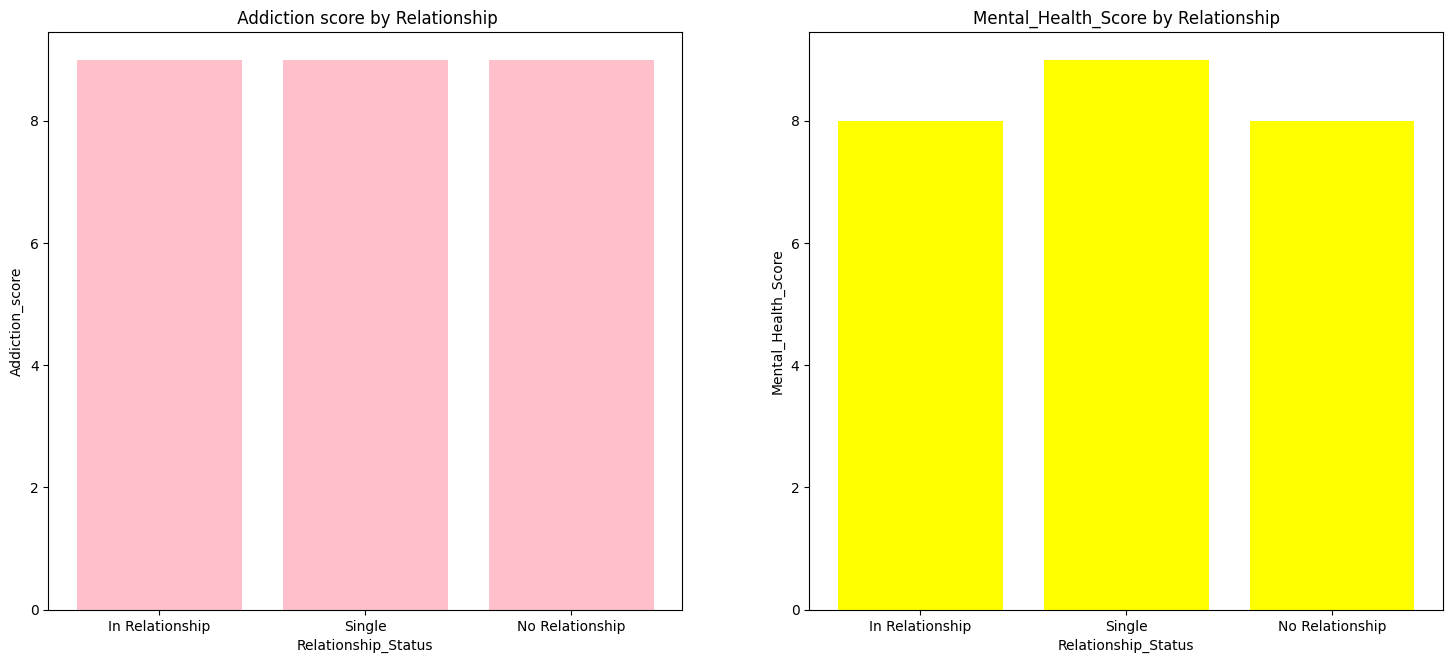

In [45]:
# fig1 , ax1 = plt.subplot(2,2 , figsize = (10,15))
# ax[0,0].bar(Df["Relationship_Status"] , Df["Addicted_Score"] , color = "Pink")


fig1 , ax1 = plt.subplots(1,2,figsize = (18,7.5))
fig.suptitle("Analyize the Addiction scores across different student demographics")

ax1[0].bar(Df["Relationship_Status"] , Df["Addicted_Score"] , color = "Pink")
ax1[0].set_xlabel("Relationship_Status")
ax1[0].set_ylabel("Addiction_score")
ax1[0].set_title(" Addiction score by Relationship")


ax1[1].bar(Df["Relationship_Status"] , Df["Mental_Health_Score"] , color = "Yellow")
ax1[1].set_xlabel("Relationship_Status")
ax1[1].set_ylabel("Mental_Health_Score")
ax1[1].set_title("Mental_Health_Score by Relationship")

# plt.tight_layout()

# Analysis The relationship between Avg daily hour and mental health score

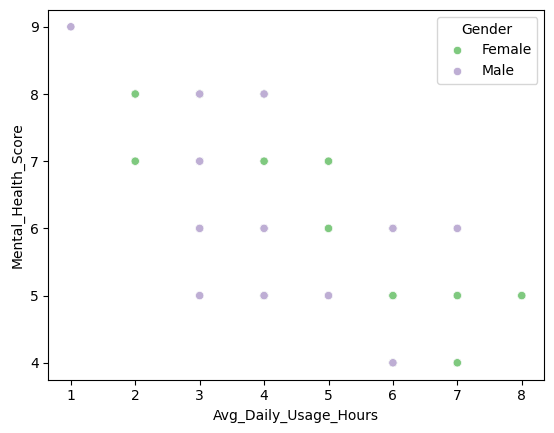

In [46]:
sns.scatterplot(x = "Avg_Daily_Usage_Hours" , y =  "Mental_Health_Score" ,data = Df , hue = "Gender" , palette = 'Accent') 
plt.show()

# Analysis The relationship between sleep per night and mental health score

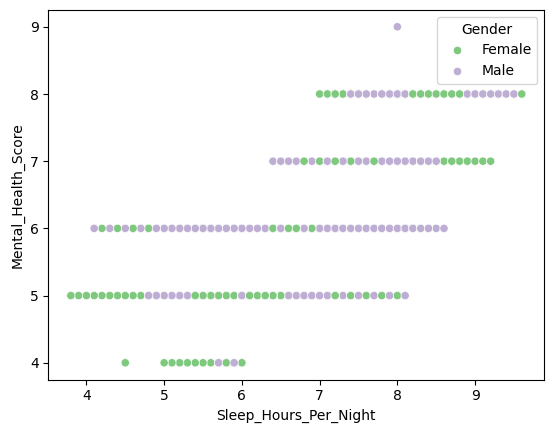

In [29]:
sns.scatterplot(x = "Sleep_Hours_Per_Night" , y =  "Mental_Health_Score" ,data = Df , hue = "Gender" , palette = 'Accent') 
plt.show()

In [47]:
Df.head(5)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Conflicts_Over_Social_Media_category,Addicted_Score_category
0,1,19,Female,Undergraduate,Bangladesh,5,Instagram,Yes,6.5,6,In Relationship,3,8,Medium,High
1,2,22,Male,Graduate,India,2,Twitter,No,7.5,8,Single,0,3,Low,Low
2,3,20,Female,Undergraduate,USA,6,TikTok,Yes,5.0,5,No Relationship,4,9,Medium,High
3,4,18,Male,High School,UK,3,YouTube,No,7.0,7,Single,1,4,Low,Low
4,5,21,Male,Graduate,Canada,4,Facebook,Yes,6.0,6,In Relationship,2,7,Low,Medium


In [54]:
Averge_Mental_health_of_relationship = Df.groupby("Relationship_Status")["Mental_Health_Score"].mean()

In [55]:
Averge_Mental_health_of_relationship

Relationship_Status
In Relationship    6.297578
No Relationship    5.937500
Single             6.197917
Name: Mental_Health_Score, dtype: float64

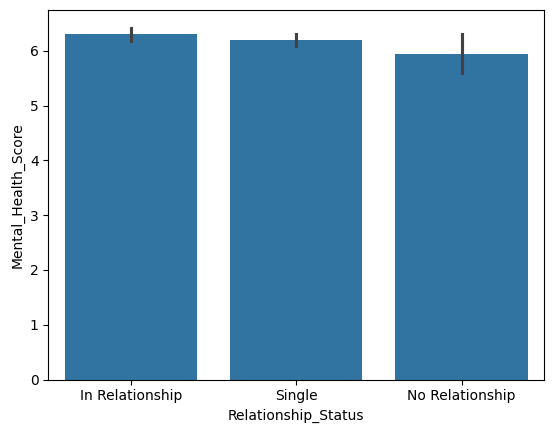

In [58]:
sns.barplot(x="Relationship_Status" , y="Mental_Health_Score" , data=Df)
plt.show()